# Fake News Detection Model


- PHASE 1: DATASET UNDERSTANDING


In [1]:
import pandas as pd
import numpy as np

# Load Datasets
fake_df = pd.read_csv("../dataset/Fake.csv")
true_df = pd.read_csv("../dataset/True.csv")

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

print("\nFake News Dataset Shape :", fake_df.shape)
print("True News Dataset Shape :", true_df.shape)

Datasets Loaded Successfully

Fake News Dataset Shape : (23481, 4)
True News Dataset Shape : (21417, 4)


In [2]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 60)
print("Fake News Dataset")
print("=" * 60)

display(fake_df.head())

print("\n")

print("=" * 60)
print("True News Dataset")
print("=" * 60)

display(true_df.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"




True News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Fake Dataset Information")
print("=" * 60)

fake_df.info()

print("\n")

print("=" * 60)
print("True Dataset Information")
print("=" * 60)

true_df.info()

Fake Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


True Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [4]:
# ==========================================================
# Missing Values & Duplicate Records
# ==========================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)

print("\nFake Dataset")

print(fake_df.isnull().sum())

print("\nTrue Dataset")

print(true_df.isnull().sum())

print("\n")

print("=" * 60)
print("Duplicate Records")
print("=" * 60)

print("Fake Dataset :", fake_df.duplicated().sum())

print("True Dataset :", true_df.duplicated().sum())

Missing Values

Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64

True Dataset
title      0
text       0
subject    0
date       0
dtype: int64


Duplicate Records
Fake Dataset : 3
True Dataset : 206


In [5]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 60)
print("Fake Dataset Summary")
print("=" * 60)

display(fake_df.describe(include="all"))

print()

print("=" * 60)
print("True Dataset Summary")
print("=" * 60)

display(true_df.describe(include="all"))

Fake Dataset Summary


,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46



True Dataset Summary


,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


- PHASE 2: DATA CLEANING & TEXT PREPROCESSING

In [6]:
# ==========================================================
# PHASE 3 : DATA CLEANING & PREPROCESSING
# ==========================================================

# Create Target Labels
fake_df["label"] = 0
true_df["label"] = 1

# Merge Datasets
df = pd.concat([fake_df, true_df], axis=0)

# Shuffle Dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 60)
print("Datasets Merged Successfully")
print("=" * 60)

print("Dataset Shape :", df.shape)

display(df.head())

Datasets Merged Successfully
Dataset Shape : (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [7]:
# ==========================================================
# Remove Missing Values & Duplicates
# ==========================================================

print("=" * 60)
print("Before Cleaning")
print("=" * 60)

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

# Remove Missing Values
df.dropna(inplace=True)

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Reset Index
df.reset_index(drop=True, inplace=True)

print("\n")

print("=" * 60)
print("After Cleaning")
print("=" * 60)

print("Dataset Shape :", df.shape)

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Before Cleaning
Missing Values
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows : 209


After Cleaning
Dataset Shape : (44689, 5)
Missing Values
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows : 0


In [8]:
# ==========================================================
# Text Cleaning
# ==========================================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("=" * 60)
print("Cleaning News Articles...")
print("=" * 60)
# Remove rows with missing text
df = df.dropna(subset=["text"])

# Convert to string
df["text"] = df["text"].astype(str)

# Clean text
df["text"] = df["text"].apply(clean_text)

print("Text Cleaning Completed Successfully")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\G\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning News Articles...
Text Cleaning Completed Successfully


In [9]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

import os

os.makedirs("../dataset", exist_ok=True)

df.to_csv(
    "../dataset/processed_fake_news.csv",
    index=False
)

print("=" * 60)
print("Processed Dataset Saved Successfully")
print("=" * 60)

print("Saved File : ../dataset/processed_fake_news.csv")

Processed Dataset Saved Successfully
Saved File : ../dataset/processed_fake_news.csv


- PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

In [10]:
# ==========================================================
# PHASE 4 : EXPLORATORY DATA ANALYSIS
# ==========================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../charts", exist_ok=True)

print("=" * 60)
print("EDA Started")
print("=" * 60)

EDA Started


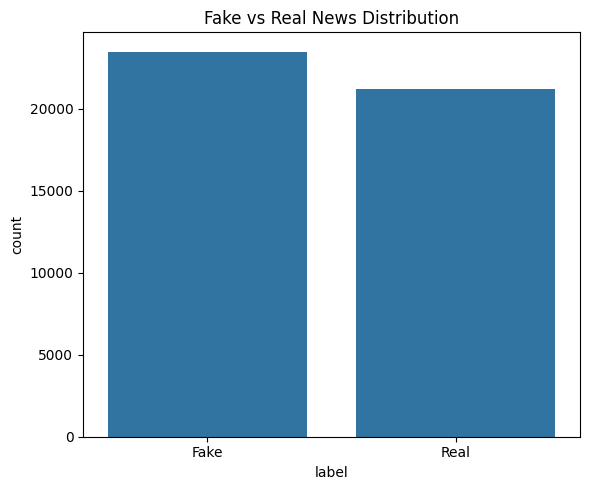

In [11]:
# ==========================================================
# Fake vs Real News Distribution
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="label"
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Fake vs Real News Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/news_distribution.png",
    dpi=300
)

plt.show()

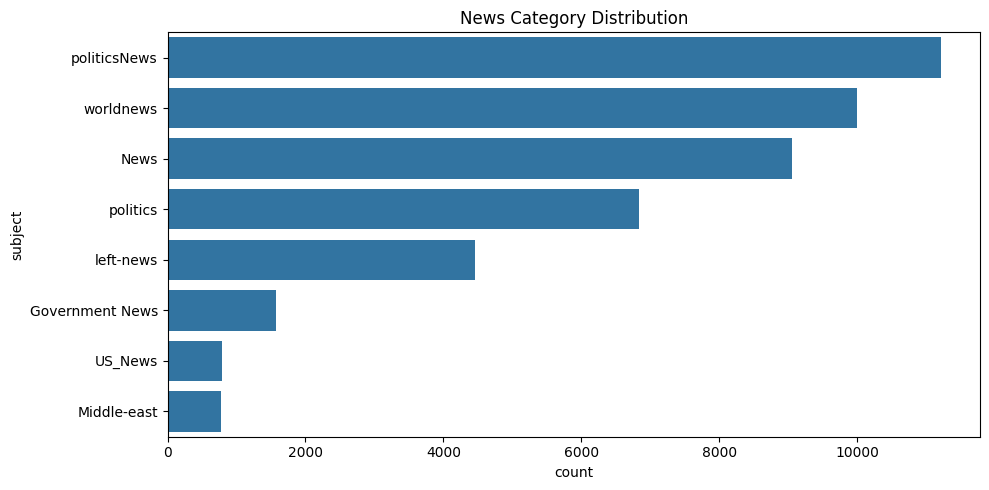

In [12]:
# ==========================================================
# Subject Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="subject",
    order=df["subject"].value_counts().index
)

plt.title("News Category Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/subject_distribution.png",
    dpi=300
)

plt.show()

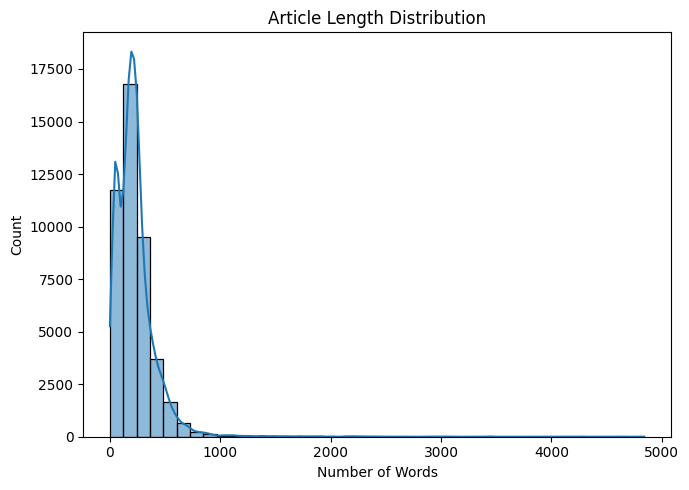

In [13]:
# ==========================================================
# Article Length Distribution
# ==========================================================

df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(7,5))

sns.histplot(
    df["word_count"],
    bins=40,
    kde=True
)

plt.title("Article Length Distribution")

plt.xlabel("Number of Words")

plt.tight_layout()

plt.savefig(
    "../charts/article_length_distribution.png",
    dpi=300
)

plt.show()

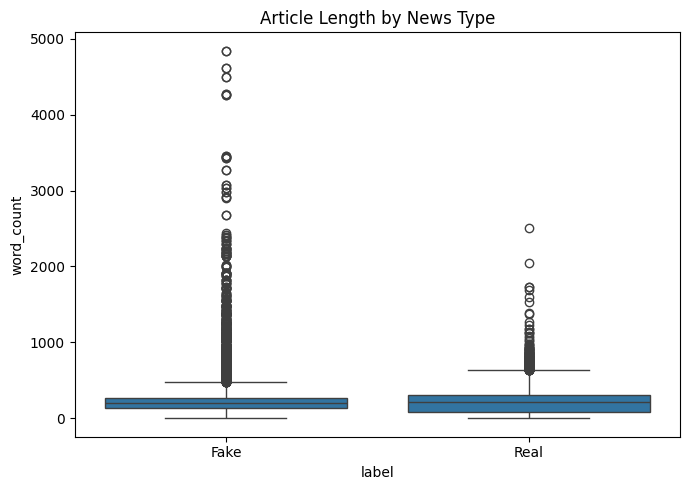

In [14]:
# ==========================================================
# Fake vs Real Article Length
# ==========================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Article Length by News Type")

plt.tight_layout()

plt.savefig(
    "../charts/fake_vs_real_length.png",
    dpi=300
)

plt.show()

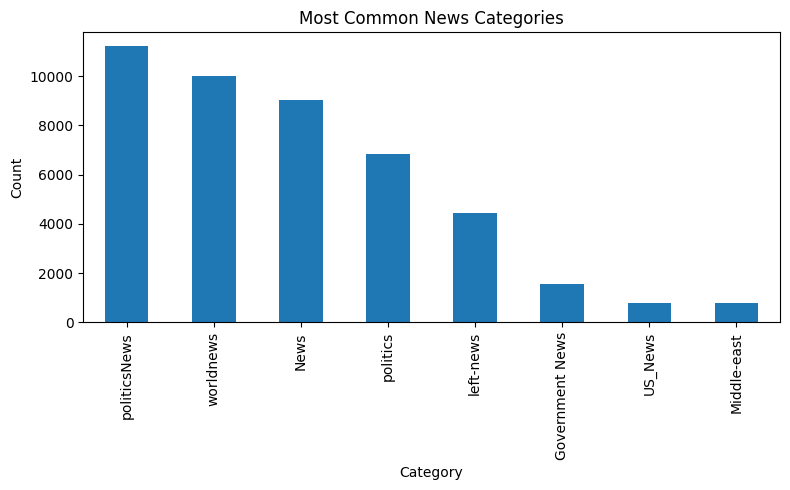

In [15]:
# ==========================================================
# Top News Categories
# ==========================================================

category_counts = df["subject"].value_counts()

plt.figure(figsize=(8,5))

category_counts.plot(kind="bar")

plt.title("Most Common News Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../charts/top_news_categories.png",
    dpi=300
)

plt.show()

- PHASE 4: FEATURE ENGINEERING

In [16]:
# ==========================================================
# PHASE 5 : FEATURE ENGINEERING
# ==========================================================

# Load Processed Dataset
df = pd.read_csv("../dataset/processed_fake_news.csv")

print("=" * 60)
print("Processed Dataset Loaded Successfully")
print("=" * 60)

print("Dataset Shape :", df.shape)

display(df.head())

Processed Dataset Loaded Successfully
Dataset Shape : (44689, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,st centuri wire say ben stein reput professor ...,US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,washington reuter us presid donald trump remov...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,reuter puerto rico governor ricardo rossello s...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,monday donald trump embarrass countri accident...,News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,glasgow scotland reuter us presidenti candid g...,politicsNews,"June 24, 2016",1


In [17]:
# ==========================================================
# Features and Target
# ==========================================================

X = df["text"]

y = df["label"]

print("=" * 60)
print("Feature & Target Created")
print("=" * 60)

print("Number of News Articles :", len(X))
print("Target Shape :", y.shape)

print("\nTarget Distribution")

print(y.value_counts())

Feature & Target Created
Number of News Articles : 44689
Target Shape : (44689,)

Target Distribution
label
0    23478
1    21211
Name: count, dtype: int64


In [18]:
# ==========================================================
# TF-IDF Vectorization
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    stop_words="english",

    max_df=0.7,

    min_df=2,

    max_features=5000

)

X_tfidf = tfidf.fit_transform(X)

print("=" * 60)
print("TF-IDF Vectorization Completed")
print("=" * 60)

print("Feature Matrix Shape :", X_tfidf.shape)

ValueError: np.nan is an invalid document, expected byte or unicode string.

In [ ]:
# ==========================================================
# Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("=" * 60)
print("Train Test Split Completed")
print("=" * 60)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

In [ ]:
# ==========================================================
# Save TF-IDF Vectorizer
# ==========================================================

import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(

    tfidf,

    "../model/tfidf_vectorizer.pkl"

)

print("=" * 60)
print("TF-IDF Vectorizer Saved Successfully")
print("=" * 60)

print("Saved File : ../model/tfidf_vectorizer.pkl")

- PHASE 5 : MODEL TRAINING & EVALUATION

In [ ]:
# ==========================================================
# PHASE 6 : MODEL TRAINING & EVALUATION
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import joblib
import os

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Passive Aggressive": PassiveAggressiveClassifier(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(random_state=42)

}

results = []

trained_models = {}

print("="*60)
print("Models Initialized Successfully")
print("="*60)

In [ ]:
# ==========================================================
# Train Models
# ==========================================================

for name, model in models.items():

    print("="*60)
    print(f"Training {name}")
    print("="*60)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    trained_models[name] = model

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

print("="*60)
print("All Models Trained Successfully")
print("="*60)

In [ ]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by=["Accuracy","F1 Score"],

    ascending=False

).reset_index(drop=True)

print("="*60)
print("Model Comparison")
print("="*60)

display(results_df)

In [ ]:
# ==========================================================
# Best Model Evaluation
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

prediction = best_model.predict(X_test)

print("="*60)
print("Best Model :", best_model_name)
print("="*60)

print(classification_report(y_test, prediction))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    prediction,

    cmap="Blues"

)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.savefig(

    "../reports/figures/confusion_matrix.png",

    dpi=300

)

plt.show()

In [ ]:
# ==========================================================
# Save Best Model
# ==========================================================

os.makedirs("../model", exist_ok=True)

joblib.dump(

    best_model,

    "../model/fake_news_model.pkl"

)

print("="*60)
print("Best Model Saved Successfully")
print("="*60)

print("Model Name :", best_model_name)

print("Saved File : ../model/fake_news_model.pkl")

In [ ]:
# ==========================================================
# Final Summary
# ==========================================================

print("="*60)
print("FAKE NEWS DETECTION MODEL TRAINING COMPLETED")
print("="*60)

print(f"""
Selected Model : {best_model_name}

Dataset        : Fake & Real News

Vectorizer     : TF-IDF

Model Saved    : fake_news_model.pkl

Vectorizer     : tfidf_vectorizer.pkl
""")

display(results_df)